In [73]:
import math
import random
import sys
!{sys.executable} -m pip install openpyxl
import time
import sys
!{sys.executable} -m pip install matplotlib numpy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
class TMLPAProblem:
    def __init__(self, d, f, o, L, q, w, d_max, P, P_min):
        self.d         = d
        self.f         = f
        self.o         = o
        self.L         = L
        self.q         = q
        self.w         = w
        self.d_max     = d_max
        self.P         = P
        self.P_min     = P_min
        self.n_clients = len(q)
        self.n_hubs    = len(f)

    def fo_eval(self, x, y):
        total = 0
        for j in range(self.n_hubs):
            total += self.f[j] * y[j]
            for c in range(self.n_clients):
                if x[c] == j:
                    total += self.o[j] * self.q[c]
        for c in range(self.n_clients):
            total += self.w[c] * self.d[c][x[c]]
        return total

    def is_feasible(self, x, y):
        for c in range(self.n_clients):
            if y[x[c]] != 1:
                return False
        for j in range(self.n_hubs):
            if y[j] == 1:
                load = 0
                for c in range(self.n_clients):
                    if x[c] == j:
                        load += self.q[c]
                if load > self.L[j]:
                    return False
        for c in range(self.n_clients):
            if self.d[c][x[c]] > self.d_max:
                return False
        n_open = 0
        for j in range(self.n_hubs):
            n_open += y[j]
        if n_open < self.P_min or n_open > self.P:
            return False
        return True

In [75]:
def sigmoid(v):
    if v >= 0:
        return 1.0 / (1.0 + math.exp(-v))
    z = math.exp(v)
    return z / (1.0 + z)

In [76]:
"""
FUNCIONAMIENTO DEL COATI:

ecuaciones coati
x_i: posición actual del coatí i  
lb, ub : límites inferior y superior 
Iguana: mejor solución (posición del mejor coati)
Inicialización: x_ij = lb_j + r * (ub_j - lb_j)
len de algo para ver cuántas dimensiones tiene el espacio
v variable de valor temporal
"""

class CoatiMov:
    #Posición inicial aleatoria dentro de lb, ub (paper(1))
    def __init__(self, lb, ub):
        self.lb = lb
        self.ub = ub
        m = len(lb)
        self.x = [lb[j] + random.random() * (ub[j] - lb[j]) for j in range(m)]

    def cazar_arbol(self, iguana):
        """
        Mitad de coatis suben al árbol para bajar a la iguana (paper (4))
        x_i^p1_j = x_i,j + r * (iguana_j - I * x_i,j) con I entero rand de 1 a 2
        """
        m = len(self.x)
        x_p1 = []

        for j in range(m):
            I = random.randint(1, 2)
            r = random.random()
            v = self.x[j] + r * (iguana[j] - I * self.x[j])
            v = max(self.lb[j], min(self.ub[j], v))
            x_p1.append(v)
        return x_p1
    
    def cazar_piso(self,iguana_piso):
        """
        Mitad de coatis para ir donde la iguana cuando cae, pero (paper (6)):
        Si F_iguana_piso < F_i:
            x_i^p1_j = x_i,j + r * (iguana_piso_j - x_i,j)
          si no:
            x_i^p1_j = x_i,j + r * (x_i,j - iguana_piso_j)
        """
        m = len(self.x)
        x_p1 = []

        for j in range(m):
            r = random.random()
            v = self.x[j] + r * (iguana_piso[j] - self.x[j])
            v = max(self.lb[j], min(self.ub[j], v))
            x_p1.append(v)
        return x_p1
    
    def escape(self, t, T):
        """
        Coati corre del depredador y lo hace cerca de su posición (paper (8,9))
        lb_j^local = lb_j / t
        ub_j^local = ub_j / t
        x_i^p2_j = x_i,j + (1 - 2r) * (lb_j^local + r * (ub_j^local - lb_j^local))
        t iteración (1,2,....T)
        T total de iteraciones
        """

        m = len(self.x)
        x_p2 = []

        for j in range(m):
            lb_local = self.lb[j] / t
            ub_local = self.ub[j] / t
            r = random.random()
            v = self.x[j] + (1 - 2 * r) * (lb_local + r * (ub_local - lb_local))
            v = max(self.lb[j], min(self.ub[j], v))
            x_p2.append(v)
        return x_p2
    
    def actualizar_pos(self, x_new, f_actual, f_new):
        """
        Acepta la nueva posición solo si la funcion objetivo es superada, la mejora (paper (7,10))
        X_i = x_new  si  F_new < F_current
        X_i = x_i    else
        """

        if f_new < f_actual:
            self.x = x_new
    
    def pass_to_binary(self): 
        """
        Convierte la posición del coatí al vector binario de los hubs.
        si random < sigmoid, hub j abierto
        """

        y = []
        for j in range(len(self.x)):
            if random.random() < sigmoid(self.x[j]):
                y.append(1)
            else:
                y.append(0)
        return y

In [77]:
class Coati:
    """
    Para el movimiento (particula)
    """
    def __init__(self, problem):
        self.problem = problem

        lb = [-6.0] * problem.n_hubs
        ub = [ 6.0] * problem.n_hubs
        self.mov = CoatiMov(lb, ub)

        while True:
            n_open = random.randint(problem.P_min, problem.P)
            hubs   = random.sample(range(problem.n_hubs), n_open)
            y = [0] * problem.n_hubs
            for j in hubs:
                y[j] = 1
            open_hubs = []
            for j in range(problem.n_hubs):
                if y[j] == 1:
                    open_hubs.append(j)
    
            x = []
            valido = True
            for c in range(problem.n_clients):
                accesibles = []
                for j in open_hubs:
                    if problem.d[c][j] <= problem.d_max:
                        accesibles.append(j)
                if len(accesibles) == 0:
                    valido = False
                    break
                x.append(random.choice(accesibles))
    
            if valido and problem.is_feasible(x, y):
                break

        self.position_y = y
        self.position_x = x
        self.best_y     = self.position_y[:]
        self.best_x     = self.position_x[:]
        self.best_value = problem.fo_eval(self.position_x, self.position_y)

    def fitness(self):
        return self.problem.fo_eval(self.position_x, self.position_y)

    def update_best(self):
        current = self.fitness()
        if current < self.best_value:
            self.best_y     = self.position_y[:]
            self.best_x     = self.position_x[:]
            self.best_value = current

    def move(self, g_best_y, t, T):
        # guarda estado anterior 
        prev_y = self.position_y[:]
        prev_x = self.mov.x[:]

        while True:
            self.position_y = prev_y[:]
            self.mov.x      = prev_x[:]

            # Fase 1
            if random.random() < 0.5:
                # paper (4) sube arbol 
                x_norm = self.mov.cazar_arbol([float(v) for v in g_best_y])
            else:
                # paper (6) ataca iguana en el piso
                iguana_piso = [self.mov.lb[j] + random.random() * (self.mov.ub[j] - self.mov.lb[j])
                               for j in range(self.problem.n_hubs)]
                x_norm = self.mov.cazar_piso(iguana_piso)

            # misma estructura del otro sigmoid(position_y[j] + v)
            for j in range(self.problem.n_hubs):
                v = x_norm[j]
                if random.random() < sigmoid(self.position_y[j] + v):
                    self.position_y[j] = 1
                else:
                    self.position_y[j] = 0

            open_hubs = []
            for j in range(self.problem.n_hubs):
                if self.position_y[j] == 1:
                    open_hubs.append(j)
            if len(open_hubs) == 0:
                continue

            x = []
            for c in range(self.problem.n_clients):
                x.append(random.choice(open_hubs))

            if not self.problem.is_feasible(x, self.position_y):
                continue

            self.mov.x      = x_norm
            self.position_x = x

            # Fase 2  paper (ecuacioesn 8,9) escape 
            prev_y_fase2 = self.position_y[:]  # guardar antes de fase 2
            x_p2_norm = self.mov.escape(t, T)

            for j in range(self.problem.n_hubs):
                v = x_p2_norm[j]
                if random.random() < sigmoid(self.position_y[j] + v):
                    self.position_y[j] = 1
                else:
                    self.position_y[j] = 0

            open_hubs_p2 = []
            for j in range(self.problem.n_hubs):
                if self.position_y[j] == 1:
                    open_hubs_p2.append(j)

            if len(open_hubs_p2) > 0:
                x_p2 = []
                for c in range(self.problem.n_clients):
                    x_p2.append(random.choice(open_hubs_p2))
                if self.problem.is_feasible(x_p2, self.position_y):
                    self.mov.x      = x_p2_norm
                    self.position_x = x_p2
                else:
                    self.position_y = prev_y_fase2[:]  
            else:
                self.position_y = prev_y_fase2[:]  

            return

In [78]:
class COAConfig:
    def __init__(self,
                 n_coatis = 20,
                 max_iter = 100,
                 seed     = None,
                 verbose  = True):
        self.n_coatis = n_coatis
        self.max_iter = max_iter
        self.seed     = seed
        self.verbose  = verbose

In [79]:
class COAResult:
    def __init__(self, best_y, best_x, best_value, history):
        self.best_y     = best_y
        self.best_x     = best_x
        self.best_value = best_value
        self.history    = history

In [80]:
class COASolver:
    def __init__(self, problem, config=None):
        self.problem      = problem
        self.cfg          = config if config is not None else COAConfig()
        self.population   = []
        self.g_best_y     = None
        self.g_best_x     = None
        self.g_best_value = math.inf
        if self.cfg.seed is not None:
            random.seed(self.cfg.seed)

    def _init_population(self):
        self.population = []
        for i in range(self.cfg.n_coatis):
            self.population.append(Coati(self.problem))
        best = self.population[0]
        for c in self.population:
            if c.best_value < best.best_value:
                best = c
        self.g_best_y     = best.best_y[:]
        self.g_best_x     = best.best_x[:]
        self.g_best_value = best.best_value

    def _update_global_best(self):
        for c in self.population:
            if c.best_value < self.g_best_value:
                self.g_best_y     = c.best_y[:]
                self.g_best_x     = c.best_x[:]
                self.g_best_value = c.best_value

    def _log(self, t):
        x_named = []
        for j in self.g_best_x:
            x_named.append("H" + str(j + 1))
        print("iter", t, "| fo =", round(self.g_best_value, 2), "| y =", self.g_best_y, "| x =", x_named)

    def solve(self):
        self._init_population()
        history = [self.g_best_value]
        if self.cfg.verbose:
            self._log(0)
        for t in range(1, self.cfg.max_iter + 1):
            for c in self.population:
                c.move(self.g_best_y, t, self.cfg.max_iter)
                c.update_best()
            self._update_global_best()
            history.append(self.g_best_value)
            if self.cfg.verbose:
                self._log(t)
        return COAResult(self.g_best_y, self.g_best_x, self.g_best_value, history)

In [81]:
def crear_instances():
    instances = {}
    # 5 clientes 3 hubs
    instances["Small"] = TMLPAProblem(
            d     = [
                        [ 5,  8, 11],
                        [ 7,  4, 10],
                        [10,  8,  6],
                        [ 9,  5,  7],
                        [ 8,  9,  5],
                    ],
            f     = [20, 25, 15],
            o     = [0.8, 1.2, 0.6],
            L     = [6, 8, 7],
            q     = [2, 3, 2, 3, 2],
            w     = [1.0, 1.5, 0.8, 1.2, 1.0],
            d_max = 8,
            P     = 2,
            P_min = 1,
        )
    
    # 50 clientes 10 hubs
    instances["Medium"] = TMLPAProblem(
        d     = [
                        [ 5, 14,  8, 12,  6, 18, 11, 15,  9, 13],  
                        [13,  6, 11,  5, 10,  7, 14,  8, 12,  9],  
                        [ 9, 11,  4, 15,  8, 12,  6, 10, 14,  7],  
                        [12,  8, 14,  6, 11,  5,  9, 13,  7, 10],  
                        [ 7, 10,  9, 13,  4, 11,  8, 12,  6, 15],  
                        [15,  5, 12,  8, 13,  4, 10,  7, 11,  9],  
                        [ 8, 13,  7, 11,  9, 14,  5, 12,  6, 10],  
                        [11,  9, 15,  7, 12,  6, 13,  4, 10,  8],  
                        [ 6, 12,  8, 10,  7, 15,  9, 11,  5, 14],  
                        [14,  7, 10,  9, 15,  8, 11,  6, 13,  4],  
                        [ 9,  5, 12,  6, 11,  8, 14,  7, 10, 13],  
                        [11, 13,  6, 14,  8, 10,  5,  9, 12,  7], 
                        [ 7,  9, 11,  4, 13,  6, 10,  8, 15,  5],  
                        [12,  6, 15,  9,  7, 11, 13,  5,  8, 10],  
                        [ 8, 11,  5, 13,  9,  7, 12, 10,  4, 14],  
                        [10,  8, 14,  5, 12,  9,  7, 11, 13,  6],  
                        [ 5, 12,  9, 11,  6, 14,  8, 13,  7, 10],  
                        [13,  4, 10,  7, 12,  5, 15,  9, 11,  8],  
                        [ 9, 14,  6, 12,  8, 11,  4, 10, 13,  7],  
                        [11,  7, 13,  4,  9,  8, 12,  6, 10,  5],  
                        [ 6, 10,  8, 14,  5, 12,  9, 11,  4, 13],  
                        [14,  5, 11,  8, 13,  4, 10,  7, 12,  9],  
                        [ 8, 12,  6, 10,  7, 13,  5,  9, 11,  4],  
                        [10,  8, 13,  6, 11,  5,  9, 12,  7, 14],  
                        [ 7, 11,  9, 13,  4, 10,  8, 14,  5, 12],  
                        [15,  6, 12,  9, 14,  5, 11,  7, 13,  8],  
                        [ 9, 13,  5, 11,  8, 12,  6, 10, 14,  7],  
                        [12,  7, 14,  5, 10,  8, 13,  6,  9, 11],  
                        [ 6, 11,  8, 13,  5, 14,  9, 12,  7, 10],  
                        [13,  5, 10,  8, 12,  4, 15,  7, 11,  9],  
                        [ 8, 12,  7, 10,  9, 13,  4, 11,  6, 14],  
                        [11,  8, 14,  6, 12,  7, 13,  5, 10,  9],  
                        [ 5, 10,  9, 12,  6, 15,  8, 13,  4, 11],  
                        [14,  6, 11,  7, 13,  5, 12,  8, 10,  9],  
                        [ 9, 12,  4, 14,  8, 11,  6, 10, 13,  7],  
                        [12,  7, 13,  5, 10,  8, 14,  6, 11,  4],  
                        [ 7, 11,  8, 13,  4, 10,  9, 12,  5, 15],  
                        [13,  5, 12,  8, 14,  4, 10,  7, 11,  9],  
                        [ 8, 14,  6, 11,  9, 12,  5, 13,  7, 10],  
                        [10,  8, 13,  6, 12,  5,  9, 11,  4, 14],  
                        [ 6, 11,  9, 13,  5, 14,  8, 12,  7, 10],  
                        [14,  5, 11,  7, 12,  4, 10,  8, 13,  6],  
                        [ 9, 12,  5, 10,  8, 13,  6, 11, 14,  4],  
                        [11,  7, 14,  5, 10,  8, 12,  6,  9, 13],  
                        [ 7, 10,  8, 12,  4, 11,  9, 13,  5, 14],  
                        [13,  6, 11,  8, 14,  5, 12,  7, 10,  9],  
                        [ 8, 13,  6, 11,  9, 12,  4, 14,  7, 10],  
                        [11,  8, 14,  6, 12,  7, 13,  4, 10,  9],  
                        [ 5, 10,  9, 13,  6, 14,  8, 12,  4, 11],  
                        [12,  7, 11,  5, 10,  8, 13,  6,  9,  4],  
                    ],
            # Costos fijos para activar cada uno de los 10 hubs
            f     = [45, 50, 40, 55, 35, 60, 38, 52, 42, 48],
            # Costos operativos unitarios de los 10 hubs
            o     = [1.5, 1.8, 1.2, 1.9, 1.1, 2.0, 1.3, 1.7, 1.4, 1.6],
            # Capacidades máximas de los 10 hubs (Suma capacidad total = 295)
            L     = [30, 35, 25, 40, 20, 45, 25, 35, 20, 20],
            # Demandas individuales de los 50 clientes (Suma demanda total = 145)
            q     = [3, 2, 4, 3, 2, 5, 3, 2, 4, 1, 3, 2, 4, 3, 2, 5, 3, 2, 4, 1,3, 2, 4, 3, 2, 5, 3, 2, 4, 1,3, 2, 4, 3, 2, 5, 3, 2, 4, 1,3, 2, 4, 3, 2, 5, 3, 2, 4, 1],
            # Pesos / Prioridades de criticidad de los 50 clientes
            w     = [1.0, 1.2, 1.5, 1.0, 0.8, 1.1, 1.3, 0.9, 1.0, 1.4,0.9, 1.1, 1.2, 1.0, 0.8, 1.5, 1.1, 1.0, 1.3, 0.9, 1.2, 1.0, 1.4, 0.8, 1.1, 1.0, 1.3, 1.5, 0.9, 1.2, 1.1, 0.8, 1.0, 1.4, 1.2, 1.3, 0.9, 1.1, 1.0, 1.5, 0.8, 1.2, 1.1, 1.4, 1.0, 1.3, 0.9, 1.2, 1.0, 1.5],
            # Restricciones globales   
            d_max = 15,  # Radio de cobertura más realista para 10 hubs dispersos   
            P     = 6,   # Permite abrir hasta 6 hubs para absorber la carga de 145 unidades 
            P_min = 2,   # Obliga a abrir al menos 2 hubs para no saturar capacidades individuales
        
    )

    # 100 clientes 20 hubs
    instances ["Big"] = TMLPAProblem(
        d = [
                [4, 8, 5, 10, 8, 5, 4, 10, 12, 12, 9, 9, 4, 6, 6, 9, 12, 9, 15, 7],
                [6, 4, 10, 5, 13, 10, 5, 4, 9, 15, 11, 5, 4, 5, 14, 6, 6, 4, 8, 10],
                [13, 11, 8, 11, 4, 8, 9, 12, 11, 7, 13, 14, 12, 13, 9, 4, 10, 14, 12, 10],
                [14, 12, 14, 14, 13, 11, 12, 14, 10, 9, 12, 4, 14, 6, 15, 5, 11, 14, 8, 6],
                [9, 9, 12, 10, 5, 15, 11, 10, 13, 9, 4, 7, 13, 5, 14, 9, 4, 9, 7, 10],
                [12, 12, 15, 4, 14, 8, 11, 14, 15, 7, 12, 11, 6, 6, 12, 11, 10, 11, 4, 4],
                [6, 11, 7, 4, 8, 9, 14, 8, 10, 14, 10, 4, 5, 13, 5, 12, 9, 15, 5, 5],
                [10, 4, 12, 10, 5, 12, 15, 14, 10, 4, 9, 8, 11, 4, 12, 9, 10, 9, 4, 14],
                [14, 6, 10, 5, 15, 14, 6, 9, 14, 7, 15, 5, 14, 4, 12, 10, 12, 8, 6, 14],
                [8, 10, 9, 6, 12, 9, 12, 5, 14, 6, 13, 10, 10, 4, 15, 6, 11, 14, 4, 9],
                [11, 15, 15, 15, 15, 14, 11, 8, 10, 4, 6, 12, 9, 12, 12, 12, 6, 9, 12, 5],
                [12, 15, 9, 7, 13, 9, 5, 8, 12, 7, 7, 9, 8, 10, 4, 12, 5, 7, 12, 7],
                [4, 7, 8, 13, 7, 5, 13, 9, 5, 9, 12, 12, 6, 12, 6, 11, 11, 15, 10, 4],
                [8, 15, 13, 11, 9, 10, 7, 12, 6, 13, 14, 4, 13, 13, 11, 9, 15, 13, 5, 15],
                [4, 9, 11, 9, 14, 10, 9, 9, 7, 11, 9, 7, 6, 10, 4, 10, 10, 12, 8, 6],
                [12, 10, 9, 5, 8, 5, 8, 12, 13, 9, 4, 10, 4, 13, 10, 8, 5, 11, 13, 15],
                [9, 7, 14, 11, 8, 11, 13, 13, 9, 7, 15, 11, 12, 13, 8, 9, 4, 6, 5, 4],
                [10, 14, 11, 15, 6, 11, 12, 4, 11, 12, 6, 9, 9, 7, 13, 4, 11, 12, 13, 8],
                [15, 13, 4, 9, 15, 10, 7, 15, 5, 8, 8, 6, 10, 9, 10, 4, 13, 4, 11, 14],
                [6, 7, 4, 8, 12, 6, 15, 12, 7, 8, 11, 11, 7, 8, 12, 5, 5, 11, 13, 12],
                [12, 8, 7, 12, 5, 14, 10, 10, 11, 5, 4, 13, 10, 14, 10, 12, 9, 6, 11, 6],
                [7, 7, 7, 4, 7, 7, 5, 10, 4, 4, 10, 14, 9, 12, 4, 4, 7, 15, 10, 15],
                [8, 6, 8, 5, 8, 14, 14, 9, 7, 12, 4, 15, 9, 6, 11, 7, 10, 7, 12, 14],
                [10, 10, 12, 7, 10, 5, 11, 4, 8, 6, 11, 15, 15, 5, 6, 5, 11, 9, 12, 13],
                [4, 11, 12, 9, 8, 9, 7, 10, 4, 5, 12, 5, 13, 14, 9, 15, 5, 14, 7, 10],
                [6, 10, 6, 11, 6, 4, 6, 5, 9, 4, 5, 6, 7, 11, 10, 7, 14, 10, 4, 4],
                [6, 5, 11, 15, 5, 6, 14, 4, 9, 11, 7, 7, 7, 10, 9, 14, 6, 5, 14, 4],
                [8, 9, 14, 10, 9, 7, 4, 4, 12, 5, 5, 7, 8, 7, 6, 12, 4, 13, 14, 12],
                [8, 10, 12, 9, 9, 14, 6, 10, 4, 13, 8, 9, 9, 15, 4, 9, 12, 4, 14, 8],
                [5, 10, 15, 6, 13, 9, 11, 5, 15, 13, 15, 12, 7, 10, 14, 14, 5, 7, 7, 15],
                [9, 10, 11, 8, 14, 12, 12, 6, 10, 4, 8, 15, 4, 14, 14, 6, 7, 9, 6, 5],
                [6, 15, 13, 5, 8, 5, 5, 9, 4, 8, 9, 6, 8, 10, 5, 13, 8, 12, 12, 5],
                [14, 12, 5, 9, 8, 14, 14, 8, 11, 7, 4, 5, 5, 13, 5, 11, 10, 9, 14, 6],
                [6, 10, 4, 10, 7, 7, 4, 10, 6, 5, 6, 12, 8, 10, 6, 10, 8, 5, 4, 5],
                [13, 10, 8, 13, 4, 14, 14, 12, 15, 7, 8, 8, 13, 12, 14, 9, 4, 14, 6, 8],
                [8, 7, 10, 7, 11, 4, 10, 5, 6, 6, 14, 4, 12, 7, 5, 11, 13, 7, 10, 13],
                [15, 10, 15, 12, 9, 5, 7, 5, 11, 4, 12, 8, 15, 4, 7, 14, 4, 6, 14, 12],
                [5, 15, 4, 10, 15, 11, 13, 10, 9, 14, 6, 14, 14, 10, 10, 14, 14, 5, 5, 4],
                [7, 6, 14, 14, 6, 15, 14, 13, 8, 9, 12, 10, 15, 8, 8, 10, 6, 12, 12, 14],
                [12, 5, 4, 13, 13, 15, 6, 12, 13, 14, 13, 5, 11, 14, 7, 14, 12, 11, 4, 9],
                [8, 11, 9, 14, 15, 8, 12, 13, 13, 14, 9, 7, 6, 4, 9, 4, 13, 5, 11, 9],
                [10, 14, 6, 5, 14, 13, 5, 7, 13, 10, 6, 12, 14, 15, 5, 11, 12, 7, 14, 12],
                [11, 9, 9, 13, 14, 10, 14, 8, 9, 14, 11, 6, 7, 5, 15, 15, 4, 15, 12, 15],
                [6, 9, 4, 6, 6, 14, 6, 14, 14, 10, 15, 6, 12, 7, 12, 14, 6, 11, 12, 14],
                [4, 11, 6, 8, 9, 14, 12, 14, 11, 7, 5, 10, 15, 11, 10, 9, 4, 14, 10, 10],
                [15, 5, 9, 11, 11, 4, 5, 4, 15, 9, 9, 9, 7, 15, 12, 15, 14, 12, 11, 15],
                [13, 15, 9, 14, 7, 4, 6, 6, 14, 11, 7, 14, 11, 10, 14, 4, 9, 14, 6, 8],
                [9, 12, 8, 14, 5, 9, 7, 4, 5, 12, 6, 12, 4, 13, 11, 12, 10, 10, 15, 11],
                [5, 7, 6, 9, 7, 9, 15, 10, 15, 11, 5, 10, 5, 9, 12, 10, 5, 7, 8, 5],
                [15, 5, 9, 6, 7, 5, 5, 10, 14, 14, 11, 15, 10, 11, 15, 4, 10, 4, 5, 8],
                [12, 10, 10, 15, 9, 9, 9, 5, 9, 13, 6, 5, 4, 11, 10, 12, 9, 4, 7, 8],
                [9, 15, 8, 6, 9, 13, 11, 9, 7, 12, 4, 13, 11, 6, 7, 9, 7, 15, 11, 12],
                [7, 8, 6, 7, 11, 11, 9, 11, 14, 11, 11, 8, 10, 15, 8, 5, 14, 10, 11, 5],
                [13, 9, 10, 13, 13, 13, 12, 6, 7, 4, 6, 15, 10, 12, 11, 14, 13, 8, 13, 7],
                [8, 6, 12, 7, 15, 10, 15, 5, 13, 10, 12, 5, 9, 11, 15, 14, 6, 6, 9, 15],
                [13, 6, 6, 8, 10, 6, 6, 11, 8, 13, 7, 13, 7, 8, 7, 13, 13, 4, 8, 7],
                [13, 11, 4, 6, 6, 9, 13, 14, 6, 9, 4, 5, 7, 4, 9, 7, 5, 6, 11, 10],
                [6, 5, 12, 12, 4, 13, 14, 7, 14, 5, 10, 6, 7, 14, 8, 6, 11, 6, 13, 9],
                [15, 10, 4, 13, 11, 8, 10, 10, 15, 13, 6, 13, 6, 7, 7, 8, 15, 14, 11, 12],
                [6, 14, 13, 15, 7, 6, 12, 6, 7, 11, 15, 5, 5, 8, 14, 6, 15, 4, 11, 15],
                [14, 14, 10, 7, 12, 14, 7, 13, 10, 15, 5, 8, 8, 12, 8, 8, 7, 6, 13, 7],
                [7, 4, 14, 15, 5, 10, 12, 8, 11, 5, 6, 11, 9, 12, 5, 10, 12, 8, 5, 11],
                [14, 4, 6, 8, 9, 6, 11, 15, 15, 11, 8, 5, 15, 11, 11, 9, 9, 5, 7, 9],
                [15, 8, 8, 13, 12, 5, 5, 4, 14, 15, 9, 9, 11, 11, 10, 6, 6, 7, 6, 14],
                [14, 9, 7, 15, 11, 6, 14, 12, 7, 15, 10, 9, 10, 6, 8, 13, 9, 10, 12, 15],
                [10, 14, 14, 4, 15, 7, 11, 7, 14, 13, 7, 6, 13, 9, 11, 15, 13, 9, 15, 4],
                [14, 11, 9, 11, 14, 4, 7, 4, 8, 6, 8, 6, 11, 6, 14, 14, 6, 7, 12, 6],
                [6, 14, 8, 10, 12, 11, 4, 10, 13, 10, 8, 15, 14, 9, 6, 5, 7, 15, 11, 14],
                [8, 5, 9, 6, 10, 8, 11, 12, 15, 11, 13, 4, 4, 7, 6, 11, 10, 7, 5, 12],
                [11, 4, 13, 13, 9, 6, 7, 7, 4, 15, 5, 5, 12, 12, 12, 11, 12, 14, 11, 8],
                [14, 7, 9, 10, 14, 14, 7, 12, 13, 7, 7, 4, 14, 14, 12, 7, 14, 8, 8, 11],
                [8, 6, 12, 10, 9, 6, 7, 6, 5, 9, 14, 7, 9, 5, 13, 11, 4, 15, 4, 9],
                [13, 13, 4, 14, 13, 10, 15, 15, 9, 14, 5, 6, 14, 7, 8, 14, 10, 7, 11, 13],
                [14, 8, 7, 13, 9, 8, 11, 13, 15, 14, 8, 14, 11, 9, 12, 13, 9, 6, 11, 11],
                [12, 5, 14, 6, 6, 14, 10, 15, 4, 14, 9, 10, 14, 11, 14, 7, 7, 9, 4, 7],
                [14, 7, 6, 13, 6, 8, 7, 10, 6, 13, 12, 10, 10, 15, 7, 4, 5, 15, 14, 13],
                [15, 13, 7, 14, 6, 7, 4, 11, 9, 9, 7, 14, 10, 10, 12, 5, 12, 8, 14, 10],
                [15, 6, 13, 10, 6, 9, 7, 9, 12, 15, 13, 13, 14, 4, 6, 10, 14, 9, 11, 15],
                [5, 4, 11, 4, 13, 15, 4, 10, 5, 6, 15, 5, 6, 9, 14, 7, 8, 7, 7, 7],
                [11, 4, 4, 5, 12, 7, 11, 9, 12, 6, 15, 6, 15, 11, 15, 11, 13, 14, 13, 7],
                [5, 10, 5, 11, 5, 14, 15, 9, 14, 5, 6, 11, 13, 12, 7, 12, 6, 7, 7, 7],
                [6, 5, 8, 13, 8, 5, 7, 7, 4, 14, 8, 9, 9, 5, 7, 12, 8, 4, 5, 15],
                [15, 15, 8, 5, 14, 15, 12, 14, 12, 10, 7, 9, 9, 11, 13, 7, 12, 10, 11, 4],
                [5, 4, 5, 5, 11, 10, 7, 12, 15, 12, 15, 15, 4, 12, 15, 14, 7, 9, 15, 6],
                [6, 15, 13, 6, 13, 13, 14, 15, 8, 8, 5, 11, 4, 5, 8, 12, 5, 8, 10, 14],
                [15, 14, 11, 9, 5, 6, 11, 14, 6, 13, 12, 13, 13, 8, 12, 15, 12, 9, 11, 14],
                [14, 13, 8, 6, 7, 7, 14, 11, 9, 5, 5, 11, 7, 11, 10, 7, 15, 10, 8, 9],
                [12, 12, 15, 8, 14, 12, 13, 12, 15, 4, 15, 12, 5, 11, 14, 6, 6, 11, 10, 6],
                [14, 11, 15, 5, 8, 6, 7, 5, 5, 13, 13, 8, 9, 6, 9, 14, 10, 8, 5, 7],
                [13, 15, 4, 12, 10, 9, 10, 14, 4, 8, 7, 8, 11, 14, 12, 7, 11, 5, 7, 7],
                [14, 6, 12, 14, 8, 6, 9, 6, 8, 5, 10, 9, 7, 10, 15, 11, 6, 4, 8, 12],
                [13, 4, 15, 7, 11, 10, 6, 8, 8, 8, 4, 15, 7, 11, 7, 4, 4, 9, 8, 6],
                [10, 15, 14, 13, 5, 7, 11, 6, 4, 12, 6, 5, 6, 6, 12, 12, 12, 12, 4, 4],
                [5, 7, 11, 11, 14, 12, 12, 9, 6, 15, 10, 11, 5, 4, 15, 13, 8, 7, 14, 10],
                [13, 14, 9, 15, 12, 13, 4, 12, 6, 6, 7, 8, 6, 11, 4, 10, 6, 9, 13, 11],
                [12, 11, 15, 8, 6, 5, 7, 13, 11, 15, 9, 5, 7, 9, 14, 15, 4, 7, 8, 11],
                [14, 10, 4, 15, 13, 11, 11, 7, 7, 10, 5, 13, 12, 13, 10, 9, 5, 14, 7, 7],
                [4, 7, 12, 14, 12, 15, 7, 6, 8, 10, 8, 14, 15, 14, 6, 13, 5, 4, 8, 12],
                [8, 10, 14, 5, 4, 9, 14, 10, 10, 14, 13, 9, 13, 8, 11, 11, 10, 6, 15, 6],
                [5, 10, 14, 5, 9, 7, 15, 4, 15, 4, 10, 6, 13, 14, 5, 7, 8, 14, 9, 13],
            ],
            f = [59, 43, 53, 40, 44, 52, 40, 51, 50, 52, 36, 44, 44, 44, 47, 35, 55, 37, 52, 36],
            o = [1.4, 1.2, 1.3, 1.2, 1.3, 1.6, 1.9, 2.0, 1.7, 1.5, 1.1, 1.4, 1.9, 1.6, 1.3, 1.3, 1.3, 1.8, 1.9, 1.5],
            L = [30, 27, 24, 26, 28, 30, 33, 31, 24, 29, 28, 32, 24, 27, 31, 26, 34, 29, 29, 29],
            q = [3, 2, 4, 3, 2, 5, 3, 2, 4, 1, 3, 2, 4, 3, 2, 5, 3, 2, 4, 1, 3, 2, 4, 3, 2, 5, 3, 2, 4, 1, 3, 2, 4, 3, 2, 5, 3, 2, 4, 1, 3, 2, 4, 3, 2, 5, 3, 2, 4, 1, 3, 2, 4, 3, 2, 5, 3, 2, 4, 1, 3, 2, 4, 3, 2, 5, 3, 2, 4, 1, 3, 2, 4, 3, 2, 5, 3, 2, 4, 1, 3, 2, 4, 3, 2, 5, 3, 2, 4, 1, 3, 2, 4, 3, 2, 5, 3, 2, 4, 1],
            w = [1.0, 1.2, 1.5, 1.0, 0.8, 1.1, 1.3, 0.9, 1.0, 1.4, 1.0, 1.2, 1.5, 1.0, 0.8, 1.1, 1.3, 0.9, 1.0, 1.4, 1.0, 1.2, 1.5, 1.0, 0.8, 1.1, 1.3, 0.9, 1.0, 1.4, 1.0, 1.2, 1.5, 1.0, 0.8, 1.1, 1.3, 0.9, 1.0, 1.4, 1.0, 1.2, 1.5, 1.0, 0.8, 1.1, 1.3, 0.9, 1.0, 1.4, 1.0, 1.2, 1.5, 1.0, 0.8, 1.1, 1.3, 0.9, 1.0, 1.4, 1.0, 1.2, 1.5, 1.0, 0.8, 1.1, 1.3, 0.9, 1.0, 1.4, 1.0, 1.2, 1.5, 1.0, 0.8, 1.1, 1.3, 0.9, 1.0, 1.4, 1.0, 1.2, 1.5, 1.0, 0.8, 1.1, 1.3, 0.9, 1.0, 1.4, 1.0, 1.2, 1.5, 1.0, 0.8, 1.1, 1.3, 0.9, 1.0, 1.4],
            d_max = 15,
            P     = 15,
            P_min = 5,
    )

    return instances

In [82]:

def corridas_40(instances):
    resumen = {}
    
    for nombre, problema in instances.items():

        print("\n" + "=" * 90)
        print("INSTANCIA:", nombre)
        print("=" * 90)

        mejor_global = None
        resultados_finales = []
        historiales = []
        tiempos = []                          

        for corrida in range(1, 41):

            cfg = COAConfig(
                n_coatis = 50,
                max_iter = 500,
                seed     = corrida,
                verbose  = False
            )

            inicio = time.time()              
            solver = COASolver(problema, cfg)
            resultado = solver.solve()
            fin = time.time()                 

            tiempos.append(fin - inicio)      
            resultados_finales.append(resultado.best_value)
            historiales.append(resultado.history)

            if mejor_global is None or resultado.best_value < mejor_global.best_value:
                mejor_global = resultado

            print(
                "Corrida", corrida,
                "| Mejor FO:", round(resultado.best_value, 4),
                "| Tiempo:", round(fin - inicio, 2), "s",  
                "| Hubs:", resultado.best_y
            )

        promedio = sum(resultados_finales) / len(resultados_finales)
        mejor = min(resultados_finales)
        peor = max(resultados_finales)
        tiempo_promedio = sum(tiempos) / len(tiempos)        

        resumen[nombre] = {
            "mejor_resultado": mejor_global,
            "mejor_fo": mejor,
            "promedio_fo": promedio,
            "peor_fo": peor,
            "resultados": resultados_finales,
            "historiales": historiales,
            "tiempos": tiempos,                              
            "tiempo_promedio": tiempo_promedio               
        }

        print("\nResumen instancia:", nombre)
        print("Mejor FO    :", round(mejor, 4))
        print("Promedio FO :", round(promedio, 4))
        print("Peor FO     :", round(peor, 4))
        print("Tiempo prom :", round(tiempo_promedio, 2), "s")  
        print("Mejor hubs  :", mejor_global.best_y)

    return resumen

In [83]:
instancias = crear_instances()
resumen = corridas_40(instancias)


INSTANCIA: Small
Corrida 1 | Mejor FO: 76.9 | Tiempo: 3.58 s | Hubs: [1, 0, 1]
Corrida 2 | Mejor FO: 76.9 | Tiempo: 3.45 s | Hubs: [1, 0, 1]
Corrida 3 | Mejor FO: 76.9 | Tiempo: 3.51 s | Hubs: [1, 0, 1]
Corrida 4 | Mejor FO: 76.9 | Tiempo: 3.5 s | Hubs: [1, 0, 1]
Corrida 5 | Mejor FO: 76.9 | Tiempo: 3.43 s | Hubs: [1, 0, 1]
Corrida 6 | Mejor FO: 76.9 | Tiempo: 3.43 s | Hubs: [1, 0, 1]
Corrida 7 | Mejor FO: 76.9 | Tiempo: 3.42 s | Hubs: [1, 0, 1]
Corrida 8 | Mejor FO: 76.9 | Tiempo: 3.47 s | Hubs: [1, 0, 1]
Corrida 9 | Mejor FO: 76.9 | Tiempo: 3.49 s | Hubs: [1, 0, 1]
Corrida 10 | Mejor FO: 76.9 | Tiempo: 3.38 s | Hubs: [1, 0, 1]
Corrida 11 | Mejor FO: 76.9 | Tiempo: 3.45 s | Hubs: [1, 0, 1]
Corrida 12 | Mejor FO: 76.9 | Tiempo: 3.44 s | Hubs: [1, 0, 1]
Corrida 13 | Mejor FO: 76.9 | Tiempo: 3.42 s | Hubs: [1, 0, 1]
Corrida 14 | Mejor FO: 76.9 | Tiempo: 3.41 s | Hubs: [1, 0, 1]
Corrida 15 | Mejor FO: 76.9 | Tiempo: 3.49 s | Hubs: [1, 0, 1]
Corrida 16 | Mejor FO: 76.9 | Tiempo: 3.41 s | 

In [ ]:
import openpyxl
import statistics

def guardar_excel(resumen, nombre_archivo="resultados_COA.xlsx"):
    wb = openpyxl.Workbook()
    wb.remove(wb.active)

    # Una hoja por instancia con el historial completo 
    for nombre, datos in resumen.items():
        ws = wb.create_sheet(title=nombre[:31])

        historiales = datos["historiales"]
        n_iter = len(historiales[0])

        # Corrida  iter_0 ... iter_n  FO_final  Tiempo_s
        ws.cell(row=1, column=1, value="Corrida")
        for it in range(n_iter):
            ws.cell(row=1, column=2 + it, value=f"iter_{it}")
        ws.cell(row=1, column=2 + n_iter, value="FO_final")
        ws.cell(row=1, column=3 + n_iter, value="Tiempo_s")   

        # Filas: una por corrida
        for c, hist in enumerate(historiales):
            ws.cell(row=2 + c, column=1, value=c + 1)
            for it, val in enumerate(hist):
                ws.cell(row=2 + c, column=2 + it, value=round(val, 4))
            ws.cell(row=2 + c, column=2 + n_iter, value=round(datos["resultados"][c], 4))
            ws.cell(row=2 + c, column=3 + n_iter, value=round(datos["tiempos"][c], 4)) 

    # --- Hoja resumen con estadísticas ---
    ws = wb.create_sheet(title="Resumen", index=0)
    encabezados = ["Instancia", "Mejor", "Peor", "Promedio", "Mediana",
                   "Desv_Est", "Q1", "Q3", "Rango_Intercuartil",
                   "Tiempo_Prom_s"]                            
    for col, h in enumerate(encabezados, start=1):
        ws.cell(row=1, column=col, value=h)

    fila = 2
    for nombre, datos in resumen.items():
        res = datos["resultados"]

        desv = round(statistics.stdev(res), 4) if len(res) > 1 else 0
        if len(res) > 1:
            q1 = statistics.quantiles(res, n=4)[0]
            q3 = statistics.quantiles(res, n=4)[2]
        else:
            q1 = res[0]
            q3 = res[0]

        ws.cell(row=fila, column=1, value=nombre)
        ws.cell(row=fila, column=2, value=round(min(res), 4))
        ws.cell(row=fila, column=3, value=round(max(res), 4))
        ws.cell(row=fila, column=4, value=round(statistics.mean(res), 4))
        ws.cell(row=fila, column=5, value=round(statistics.median(res), 4))
        ws.cell(row=fila, column=6, value=desv)
        ws.cell(row=fila, column=7, value=round(q1, 4))
        ws.cell(row=fila, column=8, value=round(q3, 4))
        ws.cell(row=fila, column=9, value=round(q3 - q1, 4))
        ws.cell(row=fila, column=10, value=round(datos["tiempo_promedio"], 4))  
        fila += 1

    wb.save(nombre_archivo)
    print(f"Excel guardado como {nombre_archivo}")

In [85]:
guardar_excel(resumen, "resultados_COA.xlsx")

Excel guardado como resultados_COA.xlsx


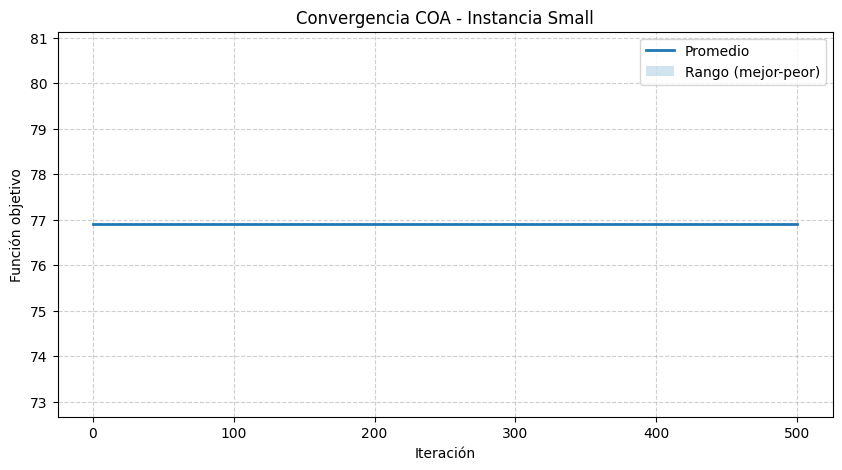

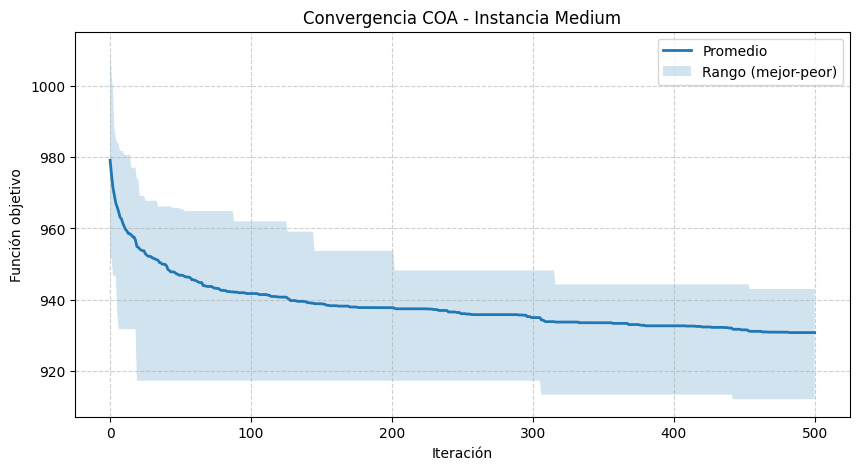

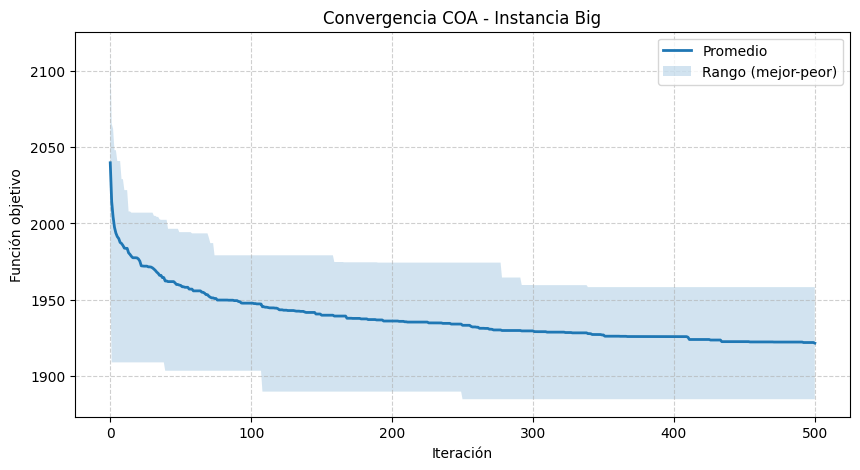

In [86]:
import matplotlib.pyplot as plt
import numpy as np

def grafico_convergencia(resumen):
    for nombre, datos in resumen.items():
        historiales = np.array(datos["historiales"])  # 40 corridas x n_iter

        # promedio, mejor y peor en cada iteración
        promedio = historiales.mean(axis=0)
        mejor    = historiales.min(axis=0)
        peor     = historiales.max(axis=0)

        plt.figure(figsize=(10, 5))
        plt.plot(promedio, label="Promedio", linewidth=2)
        plt.fill_between(range(len(promedio)), mejor, peor, alpha=0.2, label="Rango (mejor-peor)")

        plt.title(f"Convergencia COA - Instancia {nombre}")
        plt.xlabel("Iteración")
        plt.ylabel("Función objetivo")
        plt.legend()
        plt.grid(linestyle="--", alpha=0.6)
        plt.show()

grafico_convergencia(resumen)

C:\Users\migue\AppData\Local\Temp\ipykernel_22512\913632720.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos, labels=nombres, showmeans=True)


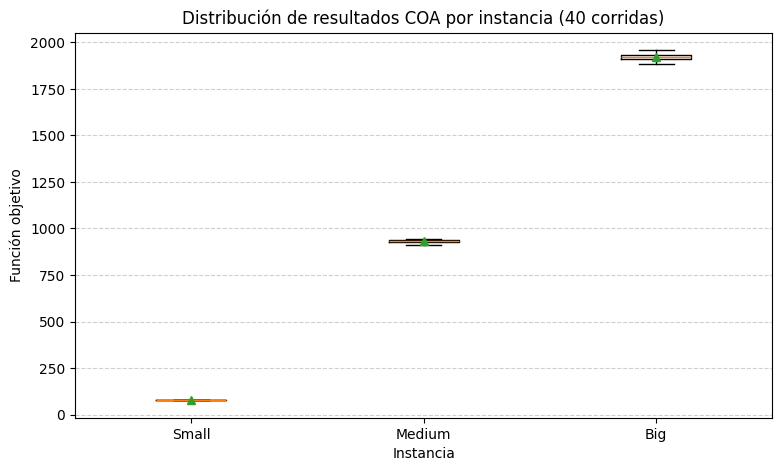

In [87]:
def grafico_caja_bigote(resumen):
    nombres = list(resumen.keys())
    datos = [resumen[nombre]["resultados"] for nombre in nombres]

    plt.figure(figsize=(9, 5))
    plt.boxplot(datos, labels=nombres, showmeans=True)

    plt.title("Distribución de resultados COA por instancia (40 corridas)")
    plt.xlabel("Instancia")
    plt.ylabel("Función objetivo")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.show()

grafico_caja_bigote(resumen)

C:\Users\migue\AppData\Local\Temp\ipykernel_22512\3888445295.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos["resultados"], labels=[nombre], showmeans=True)


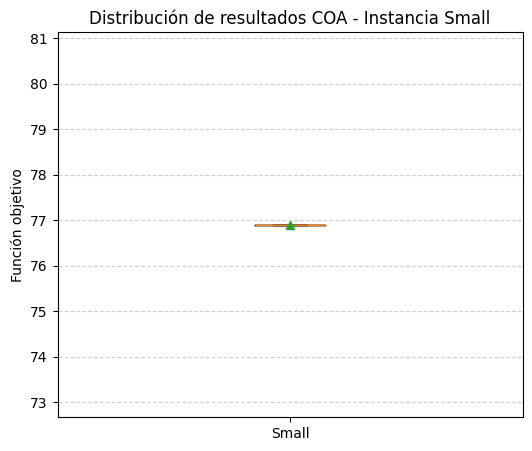

C:\Users\migue\AppData\Local\Temp\ipykernel_22512\3888445295.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos["resultados"], labels=[nombre], showmeans=True)


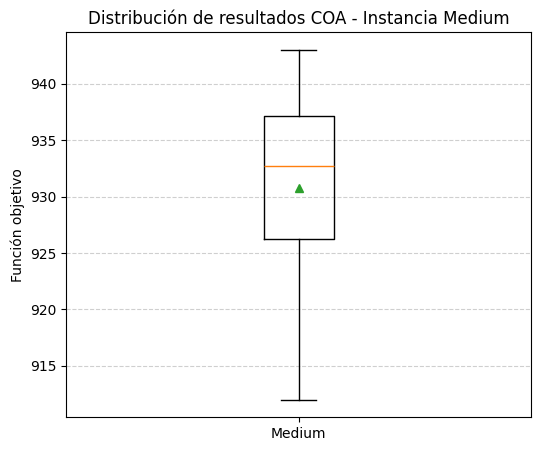

C:\Users\migue\AppData\Local\Temp\ipykernel_22512\3888445295.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos["resultados"], labels=[nombre], showmeans=True)


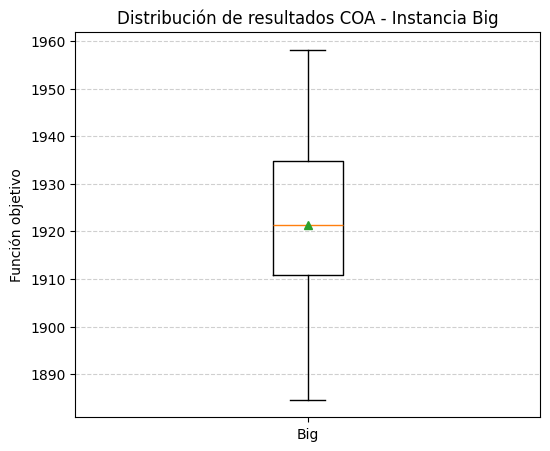

In [88]:
import matplotlib.pyplot as plt

def grafico_caja_por_instancia(resumen):
    for nombre, datos in resumen.items():
        plt.figure(figsize=(6, 5))
        plt.boxplot(datos["resultados"], labels=[nombre], showmeans=True)

        plt.title(f"Distribución de resultados COA - Instancia {nombre}")
        plt.ylabel("Función objetivo")
        plt.grid(axis="y", linestyle="--", alpha=0.6)
        plt.show()

grafico_caja_por_instancia(resumen)